# HJB-KFE Semi-Closed Form Derivation

## Polymarket BTC Digital Option Setup

We consider a binary contract (YES share) that pays at expiration time $T$:

$$
\text{Payoff}_{YES} = \mathbf{1}\{S_T \ge K\}.
$$

where $S_T$ is BTC spot at expiration and $K$ is the strike price.

Because the binary digital option satisfies

$$
\text{Payoff}_{NO} = 1 - \text{Payoff}_{YES},
$$

there exists a single fundamental price process $p_t \in (0,1)$.

Under the assumptions of frictionless conversion between YES and NO positions, symmetric microstructure, and price dynamics driven by net signed order flow, modelling the YES book alone is sufficient to capture equilibrium liquidity formation.

---

## Mean-Field State, Rank, and Control

We treat a continuum of liquidity providers (LPs) with available YES sell liquidity $q_t \in \mathbb{R}_+$ as their state variable. Let $\mu_t$ denote the distribution of $q_t$ across the LP population.

Define the rank

$$
u = F_{\mu_t}(q) \in [0,1].
$$

Each LP chooses a control $l_t \in [0,\bar l]$, interpreted as liquidity replenishment intensity.

---

## Controlled Jump Dynamics

Liquidity evolves through upward replenishment jumps and downward execution jumps.

$$
q \to q + \delta_s
$$

$$
q \to (q - \delta_b)^+
$$

where $(x)^+ = \max\{x,0\}$.

We assume time-homogeneous intensities:

$$
\lambda_s(q,\mu,l) = \phi_s(q,l)\Psi(F_\mu(q)),
$$

$$
\lambda_b(q,\mu) = \phi_b(q)\Theta(F_\mu(q)).
$$

We adopt linear rank specifications:

$$
\Psi(u) = 1 + \psi u,
$$

$$
\Theta(u) = 1 + \theta(1-u),
$$

with $\psi,\theta \ge 0$.

---

## Stationary HJB Equation

We focus on a stationary equilibrium and drop time indices.

Let $V(q;\mu)$ denote the value function of a representative LP given a stationary distribution $\mu$, with discount rate $\rho > 0$.

The stationary HJB equation is

$$
\rho V(q;\mu)
=
\max_{l \in [0,\bar l]}
\left\{
\pi(q,\mu) - c(l)
+ \lambda_s(q,\mu,l)\left[V(q+\delta_s;\mu)-V(q;\mu)\right]
+ \lambda_b(q,\mu)\left[V((q-\delta_b)^+;\mu)-V(q;\mu)\right]
\right\}.
$$

The instantaneous payoff is

$$
\pi(q,\mu)
=
m \, \phi_b(q)\Theta(F_\mu(q)) \, \delta_b \, \mathbf{1}_{\{q>0\}},
$$

where $m>0$ is a per-unit execution margin.

The control cost is quadratic:

$$
c(l) = \frac{\kappa}{2} l^2.
$$

Under the linear specification

$$
\phi_s(q,l) = a(q)l,
$$

the function $a : \mathbb{R}_+ \to \mathbb{R}_+$ represents baseline responsiveness of liquidity replenishment to the chosen control $l$.

Define

$$
\Delta^+ V(q) = V(q+\delta_s;\mu) - V(q;\mu).
$$

The optimal control is

$$
l^*(q;\mu)
=
\Pi_{[0,\bar l]}
\left(
\frac{a(q)\Psi(F_\mu(q))}{\kappa}
\Delta^+ V(q)
\right),
$$

where

$$
\Pi_{[0,\bar l]}(x) = \min\{\max\{x,0\},\bar l\}.
$$

---

## Stationary Kolmogorov Forward Equation

Define the controlled generator

$$
A^\mu f(q)
=
\lambda_s(q,\mu,l^*(q;\mu))\left[f(q+\delta_s)-f(q)\right]
+
\lambda_b(q,\mu)\left[f((q-\delta_b)^+)-f(q)\right].
$$

A stationary distribution $\mu$ satisfies

$$
\int A^\mu f(q)\,\mu(dq) = 0
$$

for all bounded test functions $f$.

---

## Mean-Field Equilibrium

A stationary mean-field equilibrium is a distribution $\mu^*$ such that

1. $V(\cdot;\mu^*)$ solves the HJB equation.
2. $\mu^*$ is invariant under the controlled dynamics induced by $l^*(\cdot;\mu^*)$.

## Algorithmic Implementation: Quantile Fixed-Point Method

We now implement the stationary mean-field equilibrium using the quantile fixed-point algorithm described in the notes.

The key idea is to represent the population distribution $\mu$ through its quantile function $Q(u)$ on a uniform rank grid

$$
u_i = \frac{i - 1/2}{N}, \qquad i = 1,\dots,N.
$$

At each outer iteration, the algorithm proceeds as follows:

1. **Fix the quantile function** $q_i \approx Q(u_i)$ and construct jump destinations for $q_i + \delta_s$ and $(q_i - \delta_b)^+$.

2. **Solve the stationary HJB equation** on the discrete grid using policy iteration to obtain:
   - the value function $V_i$,
   - the optimal control $l_i^*$.

3. **Construct the controlled Markov chain** induced by the optimal intensities and compute its stationary distribution $m_i$ using uniformization.

4. **Update the quantile function** by inverting the cumulative mass of the stationary distribution and resampling at the uniform ranks $u_i$.

5. **Apply damping** to ensure convergence:
   $$
   q_i^{new} = (1 - \omega) q_i + \omega \tilde q_i.
   $$

The fixed point of this procedure yields a stationary distribution $\mu^*$ and optimal liquidity policy $l^*(q;\mu^*)$ satisfying both the HJB and KFE equations.

In the cells below, we implement this procedure step by step.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- baseline parameters (stable starting point) ----------
N = 400                 # rank grid size
q_min, q_max = 0.0, 80.0

delta_s = 1.0           # replenishment jump size
delta_b = 1.0          # execution jump size

rho = 0.05               # discount
kappa = 0.4             # quadratic cost coefficient
l_bar = 3.0             # max control

psi = 0.3               # Psi(u) = 1 + psi*u
theta = 0.7             # Theta(u) = 1 + theta*(1-u)

m_margin = 0.45         # per-unit execution margin in pi(q,mu)

omega = 0.15             # damping for quantile update
outer_tol = 1e-6
outer_max_iter = 300

policy_tol = 1e-10
policy_max_iter = 300

np.set_printoptions(precision=4, suppress=True)

In [2]:
def proj_0_lbar(x, lbar):
    return np.minimum(np.maximum(x, 0.0), lbar)

def rank_grid(N):
    i = np.arange(1, N + 1)
    return (i - 0.5) / N

def plus(x):
    return np.maximum(x, 0.0)

def destination_indices(q, delta_s, delta_b):
    """
    For each node i, map:
      q_i -> nearest node for q_i + delta_s   (j_plus)
      q_i -> nearest node for (q_i - delta_b)^+ (j_minus)
    """
    q = np.asarray(q)
    N = q.size
    j_plus = np.empty(N, dtype=int)
    j_minus = np.empty(N, dtype=int)

    for i in range(N):
        target_plus = q[i] + delta_s
        target_minus = max(q[i] - delta_b, 0.0)

        j_plus[i] = int(np.argmin(np.abs(q - target_plus)))
        j_minus[i] = int(np.argmin(np.abs(q - target_minus)))

    return j_plus, j_minus

def quantile_from_masses(u, q, m):
    """
    Given masses m on nodes with states q (increasing),
    build cumulative M and invert to get updated quantile at u.
    """
    m = np.asarray(m)
    q = np.asarray(q)
    u = np.asarray(u)

    M = np.cumsum(m)
    M = np.clip(M, 0.0, 1.0)

    # Ensure strictly increasing cumulative for stable interpolation
    M_eps = M.copy()
    for i in range(1, len(M_eps)):
        if M_eps[i] <= M_eps[i-1]:
            M_eps[i] = M_eps[i-1] + 1e-12
    M_eps = np.clip(M_eps, 0.0, 1.0)

    # Inverse CDF/quantile: u -> q
    q_tilde = np.interp(u, M_eps, q, left=q[0], right=q[-1])
    return q_tilde

In [3]:
def solve_stationary_hjb_policy_iteration(
    q, u, j_plus, j_minus,
    rho, kappa, l_bar, psi, theta, m_margin, delta_b,
    a_func=None, phi_b_func=None,
    max_iter=200, tol=1e-10
):
    """
    Solves discrete stationary HJB on nodes i=0..N-1.

    HJB form:
      rho V_i = max_{l in [0,lbar]} { pi_i - kappa/2 l^2
                                     + lam_s_i (V_{j+}-V_i)
                                     + lam_b_i (V_{j-}-V_i) }

    with:
      lam_s_i = a(q_i) * l_i * Psi(u_i)
      lam_b_i = phi_b(q_i) * Theta(u_i)
      pi_i    = m_margin * lam_b_i * delta_b * 1{q_i>0}

    Returns:
      V (N,), l (N,)
    """
    q = np.asarray(q); u = np.asarray(u)
    N = q.size

    if a_func is None:
        a_func = lambda x: np.ones_like(x)
    if phi_b_func is None:
        phi_b_func = lambda x: np.ones_like(x)

    a_q = a_func(q)
    phi_b_q = phi_b_func(q)

    Psi = 1.0 + psi * u
    Theta = 1.0 + theta * (1.0 - u)

    # init policy and value
    l = np.zeros(N)
    V = np.zeros(N)

    for it in range(max_iter):
        # rates under current policy
        lam_s = a_q * l * Psi
        lam_b = phi_b_q * Theta

        # instantaneous payoff
        pi = m_margin * lam_b * delta_b * (q > 0).astype(float)

        # Build linear system A V = b for fixed policy l
        A = np.zeros((N, N))
        b = np.zeros(N)

        for i in range(N):
            A[i, i] = rho + lam_s[i] + lam_b[i]
            A[i, j_plus[i]] -= lam_s[i]
            A[i, j_minus[i]] -= lam_b[i]
            b[i] = pi[i] - 0.5 * kappa * (l[i] ** 2)

        # Normalization (pins down additive constant): set V at smallest q node = 0
        A[0, :] = 0.0
        A[0, 0] = 1.0
        b[0] = 0.0

        V_new = np.linalg.solve(A, b)

        # Policy update from closed form: l_i = Proj( (a(q_i)Psi_i/kappa) * (V_{j+}-V_i) )
        delta_plus_V = V_new[j_plus] - V_new
        l_raw = (a_q * Psi / kappa) * delta_plus_V
        l_new = proj_0_lbar(l_raw, l_bar)

        if np.max(np.abs(l_new - l)) < tol and np.max(np.abs(V_new - V)) < tol:
            V, l = V_new, l_new
            break

        V, l = V_new, l_new

    return V, l

In [4]:
def stationary_distribution_uniformization(j_plus, j_minus, lam_plus, lam_minus, tol=1e-14, max_iter=200000):
    """
    Build uniformized transition matrix P and compute invariant distribution m by power iteration on P^T.

    P_{i,j+} = lam_plus_i / barLambda
    P_{i,j-} = lam_minus_i / barLambda
    P_{i,i}  = 1 - (lam_plus_i + lam_minus_i)/barLambda
    """
    lam_plus = np.asarray(lam_plus)
    lam_minus = np.asarray(lam_minus)
    N = lam_plus.size

    rates = lam_plus + lam_minus
    barLambda = np.max(rates) + 1e-12

    P = np.zeros((N, N))
    for i in range(N):
        if rates[i] > 0:
            P[i, j_plus[i]] += lam_plus[i] / barLambda
            P[i, j_minus[i]] += lam_minus[i] / barLambda
            P[i, i] += 1.0 - rates[i] / barLambda
        else:
            P[i, i] = 1.0

    # power iteration on P^T
    m = np.ones(N) / N
    PT = P.T
    for _ in range(max_iter):
        m_new = PT @ m
        s = m_new.sum()
        if s <= 0:
            raise RuntimeError("Stationary iteration produced non-positive mass.")
        m_new /= s
        if np.max(np.abs(m_new - m)) < tol:
            m = m_new
            break
        m = m_new

    return m, P

iter=  1  sup|dq|=1.113e+01  E[q]=2.104  l in [0.000,3.000]
iter= 10  sup|dq|=2.659e+00  E[q]=2.021  l in [0.000,3.000]
iter= 20  sup|dq|=5.577e-01  E[q]=2.385  l in [0.000,3.000]
iter= 30  sup|dq|=2.579e-01  E[q]=2.448  l in [0.000,3.000]
iter= 40  sup|dq|=7.289e-02  E[q]=2.552  l in [0.000,3.000]
iter= 50  sup|dq|=1.158e-01  E[q]=2.544  l in [0.000,3.000]
iter= 60  sup|dq|=7.635e-02  E[q]=2.589  l in [0.000,3.000]
iter= 70  sup|dq|=1.003e-01  E[q]=2.507  l in [0.000,3.000]
iter= 80  sup|dq|=5.361e-02  E[q]=2.335  l in [0.000,3.000]
iter= 90  sup|dq|=5.285e-02  E[q]=1.966  l in [0.000,3.000]
iter=100  sup|dq|=1.390e-01  E[q]=2.215  l in [0.000,3.000]
iter=110  sup|dq|=7.381e-02  E[q]=1.964  l in [0.000,3.000]
iter=120  sup|dq|=6.090e-02  E[q]=1.978  l in [0.000,3.000]
iter=130  sup|dq|=7.045e-02  E[q]=1.974  l in [0.000,3.000]
iter=140  sup|dq|=1.503e-01  E[q]=1.898  l in [0.000,3.000]
iter=150  sup|dq|=1.111e-01  E[q]=2.107  l in [0.000,3.000]
iter=160  sup|dq|=1.479e-01  E[q]=1.939 

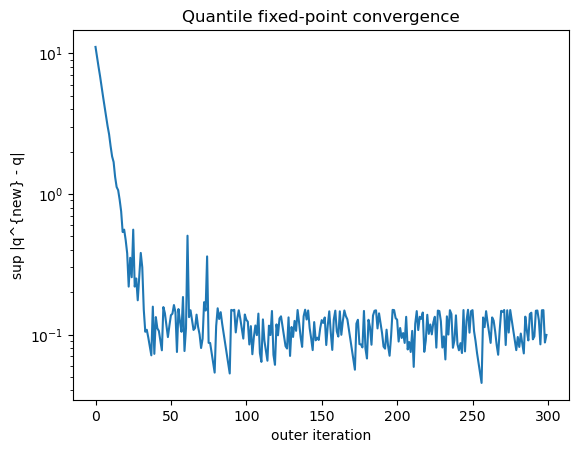

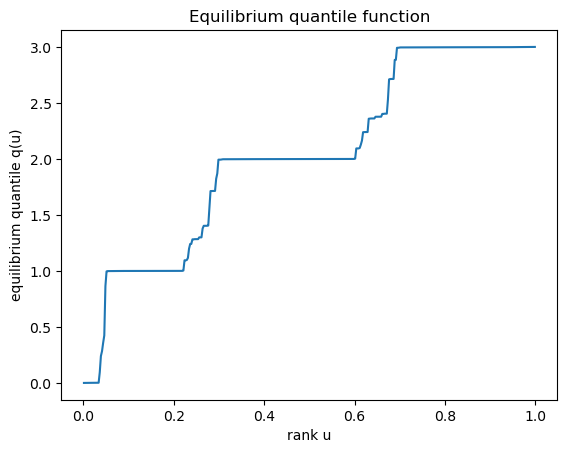

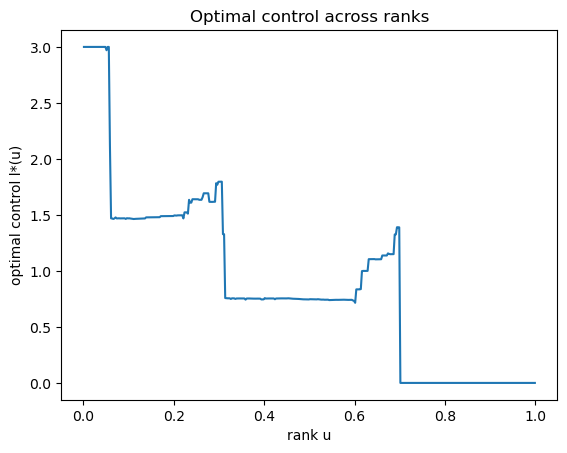

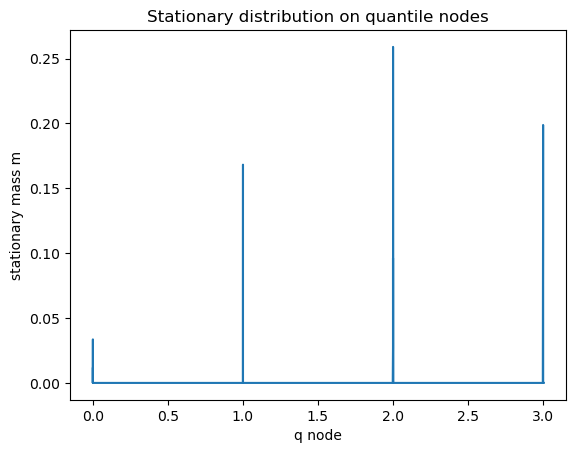

In [5]:
# Rank grid
u = rank_grid(N)

# Initialize quantile guess Q(u): increasing vector on [q_min,q_max]
q = np.linspace(q_min, q_max, N)

#define baseline a(q) and phi_b(q)
a0, a1 = 0.15, 2.5
a_func = lambda x: a0+a1/(1+q)         # a(q) = a0 + a1/(1+q)
beta = 0.04
phi_b_func = lambda x: np.exp(-beta * x)  # phi_b(q) = exp(-beta*q)

history_err = []

for k in range(outer_max_iter):
    # (i) build jump destination indices from current quantile nodes
    j_plus, j_minus = destination_indices(q, delta_s, delta_b)

    # (ii) solve HJB for V and best response l
    V, l = solve_stationary_hjb_policy_iteration(
        q=q, u=u, j_plus=j_plus, j_minus=j_minus,
        rho=rho, kappa=kappa, l_bar=l_bar,
        psi=psi, theta=theta,
        m_margin=m_margin, delta_b=delta_b,
        a_func=a_func, phi_b_func=phi_b_func,
        max_iter=policy_max_iter, tol=policy_tol
    )

    # (iii) compute controlled intensities under l*
    Psi = 1.0 + psi * u
    Theta = 1.0 + theta * (1.0 - u)
    lam_plus = a_func(q) * l * Psi
    lam_minus = phi_b_func(q) * Theta

    # (iv) stationary distribution of induced chain
    m, P = stationary_distribution_uniformization(j_plus, j_minus, lam_plus, lam_minus)

    # (v) update quantile from stationary masses, then damp
    q_tilde = quantile_from_masses(u, q, m)
    q_new = (1.0 - omega) * q + omega * q_tilde

    err = np.max(np.abs(q_new - q))
    history_err.append(err)
    q = q_new

    if (k + 1) % 10 == 0 or k == 0:
        print(f"iter={k+1:3d}  sup|dq|={err:.3e}  E[q]={np.dot(m,q):.3f}  l in [{l.min():.3f},{l.max():.3f}]")

    if err < outer_tol:
        print(f"Converged at iter {k+1} with sup|dq|={err:.3e}")
        break

# ---- quick diagnostics ----
plt.figure()
plt.semilogy(history_err)
plt.xlabel("outer iteration")
plt.ylabel("sup |q^{new} - q|")
plt.title("Quantile fixed-point convergence")
plt.show()

plt.figure()
plt.plot(u, q)
plt.xlabel("rank u")
plt.ylabel("equilibrium quantile q(u)")
plt.title("Equilibrium quantile function")
plt.show()

plt.figure()
plt.plot(u, l)
plt.xlabel("rank u")
plt.ylabel("optimal control l*(u)")
plt.title("Optimal control across ranks")
plt.show()

plt.figure()
plt.plot(q, m)
plt.xlabel("q node")
plt.ylabel("stationary mass m")
plt.title("Stationary distribution on quantile nodes")
plt.show()

# Price Process Extension: Linking Liquidity to Informational Efficiency

Up to this point, we have computed a stationary mean-field equilibrium for liquidity provision on the YES side of the digital option market.  

The HJB–KFE system delivers:

- An optimal liquidity policy $ l^*(q) $,
- A stationary liquidity distribution $  \mu^*  $,
- An endogenous depth statistic $  D  $ (e.g., $  D = \mathbb{E}_{\mu^*}[q]  $).

However, this equilibrium does not yet determine the market price dynamics of the YES share.  
To study informational efficiency, we now introduce a reduced-form price process that connects:

 $$
\text{Order Flow} \longrightarrow \text{Price Impact} \longrightarrow \text{Price Dynamics}.
 $$

---

## Fundamental Process

We introduce a latent fundamental probability process $  \pi_t \in (0,1)  $, interpreted as the true event probability.  

It follows a mean-reverting diffusion:

 $$
d\pi_t = \alpha(\bar{\pi} - \pi_t)\,dt + \sigma\, dW_t,
 $$

where:
- $   \bar{\pi}  $ is the long-run belief,
- $  \alpha  $ controls mean reversion,
- $   \sigma   $ controls information volatility.

---

## Order Flow

Buy and sell market orders arrive according to Poisson processes.  
Their intensities depend on mispricing:

 $$
\lambda^{buy}_t = \lambda_0 + \lambda_1 (\pi_t - p_t)^+,
 $$
 $$
\lambda^{sell}_t = \lambda_0 + \lambda_1 (p_t - \pi_t)^+.
 $$

Thus:
- When $  p_t < \pi_t  $, buy pressure increases.
- When $  p_t > \pi_t  $, sell pressure increases.

This captures informed trading behavior.

---

## Price Impact

The YES price $  p_t  $ evolves according to signed order flow:

 $$
dp_t = \frac{\eta}{D + \varepsilon} \, dX_t,
 $$

where:
- $  D  $ is the endogenous liquidity depth computed from the MFG equilibrium,
- $  dX_t   $ is net order flow,
- $  \eta  $ is an impact scaling parameter.

Crucially:

 $$
\text{Impact} \propto \frac{1}{D}.
 $$

Deeper equilibrium liquidity implies smaller price impact and potentially greater informational efficiency.

---

## Objective

This extension allows us to evaluate how the equilibrium liquidity structure derived from the HJB–KFE system affects:

- Tracking error $   \mathbb{E}[(p_t - \pi_t)^2]  $,
- Speed of price discovery,
- Mispricing volatility.

In this way, the liquidity equilibrium is directly linked to informational efficiency in the Polymarket digital option market.

In [6]:
# --- Depth proxies from the stationary equilibrium (computed from m, q) ---
D_mean = float(np.dot(m, q))          # mean liquidity
D_med = float(np.interp(0.5, u, q))   # median of quantile function q(u)
D_q90 = float(np.interp(0.9, u, q))   # 90th percentile depth

print("Depth proxies:")
print(f"  D_mean = {D_mean:.4f}")
print(f"  D_med  = {D_med:.4f}")
print(f"  D_q90  = {D_q90:.4f}")

# Choose one depth proxy to scale price impact
D = D_mean

Depth proxies:
  D_mean = 1.9987
  D_med  = 2.0016
  D_q90  = 3.0020


Using depth D=1.9987 -> impact coefficient = 0.0250
Tracking MSE E[(p-pi)^2] = 0.001330
Tracking MAE E[|p-pi|]   = 0.028406


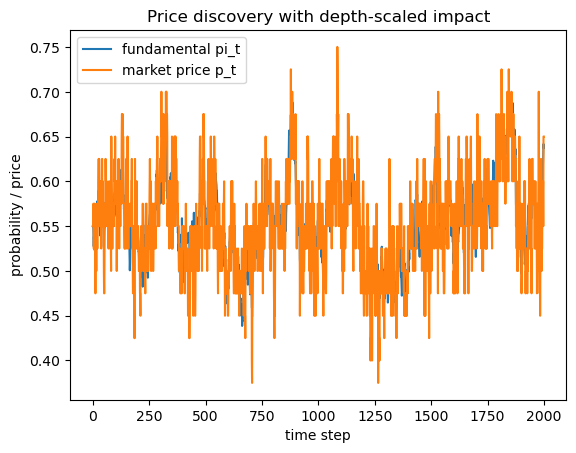

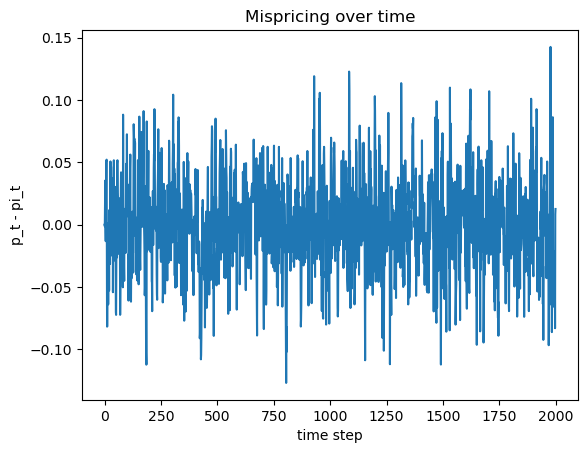

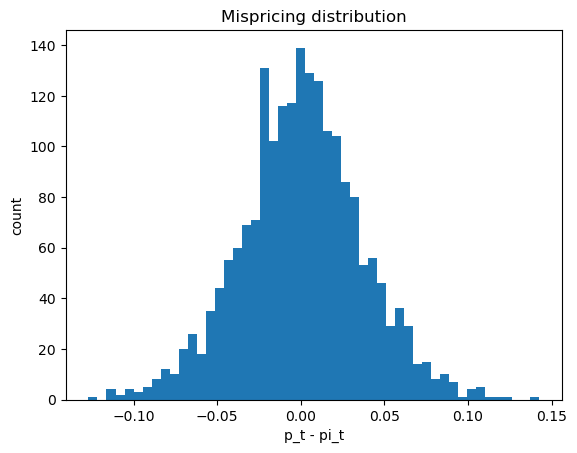

In [7]:
rng = np.random.default_rng(0)

# --- simulation settings ---
T = 2000          # number of time steps
dt = 1.0          # step size (units: "event time" or seconds; just a scale)

# --- fundamental process parameters (Ornstein-Uhlenbeck, clipped to [0,1]) ---
pi_bar = 0.55     # long-run fundamental probability
alpha = 0.02      # mean-reversion speed
sigma_pi = 0.01   # fundamental volatility per sqrt(dt)

# --- order flow parameters ---
lambda0 = 0.5     # baseline arrival rate (per dt)
lambda1 = 20.0     # sensitivity to mispricing

# --- price impact parameters ---
eta = 0.05        # impact scale (bigger = more impact per net trade)
eps_depth = 1e-6  # to avoid division by zero

impact = eta / (D + eps_depth)
print(f"Using depth D={D:.4f} -> impact coefficient = {impact:.4f}")

# --- initialize arrays ---
pi_path = np.zeros(T)
p_path = np.zeros(T)
buy_counts = np.zeros(T, dtype=int)
sell_counts = np.zeros(T, dtype=int)

# initial conditions
pi_path[0] = np.clip(pi_bar, 0.0, 1.0)
p_path[0] = np.clip(pi_bar, 0.0, 1.0)

for t in range(1, T):
    # fundamental update (OU + noise), then clip to [0,1]
    pi = pi_path[t-1] + alpha*(pi_bar - pi_path[t-1])*dt + sigma_pi*np.sqrt(dt)*rng.standard_normal()
    pi = float(np.clip(pi, 0.0, 1.0))
    pi_path[t] = pi

    # mispricing signal
    mis = pi - p_path[t-1]

    # Poisson buy/sell intensities (increase when mispricing is favorable)
    lam_buy  = max(lambda0 + lambda1*max(mis, 0.0), 0.0)
    lam_sell = max(lambda0 + lambda1*max(-mis, 0.0), 0.0)

    # sample arrivals
    nb = rng.poisson(lam_buy*dt)
    ns = rng.poisson(lam_sell*dt)
    buy_counts[t] = nb
    sell_counts[t] = ns

    # signed order flow
    dX = nb - ns

    # price update with depth-scaled impact + clip to [0,1]
    p_new = p_path[t-1] + impact * dX
    p_path[t] = float(np.clip(p_new, 0.0, 1.0))

# --- efficiency diagnostics ---
tracking_mse = float(np.mean((p_path - pi_path)**2))
tracking_mae = float(np.mean(np.abs(p_path - pi_path)))

print(f"Tracking MSE E[(p-pi)^2] = {tracking_mse:.6f}")
print(f"Tracking MAE E[|p-pi|]   = {tracking_mae:.6f}")

# --- plots ---
plt.figure()
plt.plot(pi_path, label="fundamental pi_t")
plt.plot(p_path, label="market price p_t")
plt.xlabel("time step")
plt.ylabel("probability / price")
plt.title("Price discovery with depth-scaled impact")
plt.legend()
plt.show()

plt.figure()
plt.plot(p_path - pi_path)
plt.xlabel("time step")
plt.ylabel("p_t - pi_t")
plt.title("Mispricing over time")
plt.show()

plt.figure()
plt.hist(p_path - pi_path, bins=50)
plt.xlabel("p_t - pi_t")
plt.ylabel("count")
plt.title("Mispricing distribution")
plt.show()